# Brain Tumor Detection AI

## Classificação de Tumores Cerebrais em Imagens de Ressonância Magnética utilizando Redes Neurais Convolucionais (CNN)

---

### Objetivo

Este projeto tem como objetivo desenvolver um sistema baseado em Inteligência Artificial capaz de classificar imagens de ressonância magnética cerebral em duas classes:

- Tumor
- Sem Tumor

Inicialmente foi desenvolvido um modelo baseline para validar a abordagem proposta. Após a análise de suas limitações, foi desenvolvida uma segunda versão utilizando um dataset maior e técnicas adicionais de treinamento, resultando em uma melhora significativa na capacidade de generalização.

Neste notebook são apresentadas todas as etapas do desenvolvimento:

- análise exploratória do dataset (EDA);
- pré-processamento das imagens;
- construção do modelo baseline;
- treinamento;
- avaliação do baseline;
- evolução para o modelo V2;
- comparação entre os modelos;
- conclusões.


In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
from tensorflow.keras.callbacks import EarlyStopping



In [5]:
CAMINHO_PROJETO = os.path.abspath("..")
CAMINHO_SRC = os.path.join(CAMINHO_PROJETO, "src")

if CAMINHO_SRC not in sys.path:
    sys.path.append(CAMINHO_SRC)

In [6]:
from dataset import carregar_dataset
from baseline_model import criar_modelo_baseline

# 1. Análise Exploratória dos Dados — Baseline

Nesta etapa será realizada uma análise exploratória do dataset utilizado no modelo baseline.

Os principais objetivos são:

- identificar a quantidade total de imagens;
- verificar a distribuição entre as classes;
- analisar se existe desequilíbrio entre tumor e sem tumor;
- visualizar exemplos das imagens;
- compreender as características gerais do conjunto de dados.

In [7]:
CAMINHO_DATASET_BASELINE = os.path.join(CAMINHO_PROJETO, "datasets")

print("Caminho do dataset baseline:")
print(CAMINHO_DATASET_BASELINE)

Caminho do dataset baseline:
c:\Users\arthur fernandes\Documents\Medical_AI_Project\BRAIN_TUMOR_DETECTION_AI\datasets


In [8]:
print("Pastas encontradas no dataset:")

for pasta in os.listdir(CAMINHO_DATASET_BASELINE):
    print("-", pasta)

Pastas encontradas no dataset:
- no
- yes


In [9]:
PASTA_TUMOR = os.path.join(CAMINHO_DATASET_BASELINE, "yes")
PASTA_SEM_TUMOR = os.path.join(CAMINHO_DATASET_BASELINE, "no")

arquivos_tumor = os.listdir(PASTA_TUMOR)
arquivos_sem_tumor = os.listdir(PASTA_SEM_TUMOR)

quantidade_tumor = len(arquivos_tumor)
quantidade_sem_tumor = len(arquivos_sem_tumor)
quantidade_total = quantidade_tumor + quantidade_sem_tumor

print("Quantidade de imagens com tumor:", quantidade_tumor)
print("Quantidade de imagens sem tumor:", quantidade_sem_tumor)
print("Quantidade total de imagens:", quantidade_total)

Quantidade de imagens com tumor: 155
Quantidade de imagens sem tumor: 98
Quantidade total de imagens: 253


In [12]:
percentual_tumor = (quantidade_tumor / quantidade_total) * 100
percentual_sem_tumor = (quantidade_sem_tumor / quantidade_total) * 100

print(f"Classe Tumor: {percentual_tumor:.2f}%")
print(f"Classe Sem Tumor: {percentual_sem_tumor:.2f}%")

Classe Tumor: 61.26%
Classe Sem Tumor: 38.74%


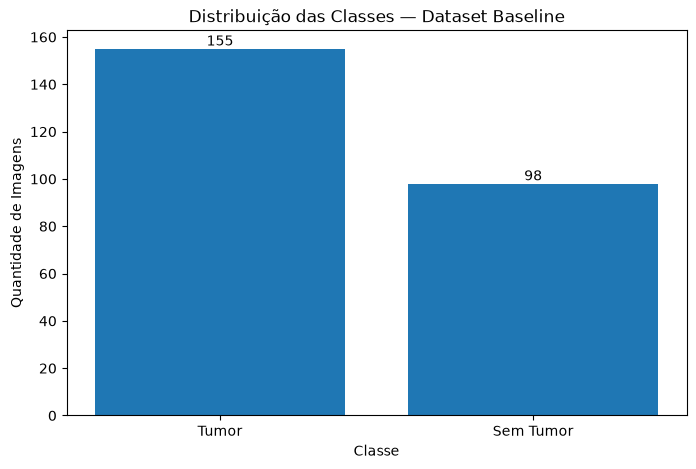

In [13]:
classes = ["Tumor", "Sem Tumor"]
quantidades = [quantidade_tumor, quantidade_sem_tumor]

plt.figure(figsize=(8, 5))
plt.bar(classes, quantidades)

plt.title("Distribuição das Classes — Dataset Baseline")
plt.xlabel("Classe")
plt.ylabel("Quantidade de Imagens")

for indice, quantidade in enumerate(quantidades):
    plt.text(
        indice,
        quantidade,
        str(quantidade),
        ha="center",
        va="bottom"
    )

plt.show()

## Interpretação da distribuição das classes

O dataset utilizado no modelo baseline é composto por **253 imagens**, sendo:

- **155 imagens da classe Tumor (61,26%)**
- **98 imagens da classe Sem Tumor (38,74%)**

Observa-se um leve desbalanceamento entre as classes, com predominância de imagens contendo tumor. Entretanto, a principal limitação deste conjunto de dados é sua pequena quantidade de imagens.

Datasets reduzidos aumentam a probabilidade de overfitting, fazendo com que a rede neural memorize características específicas das imagens de treinamento em vez de aprender padrões capazes de generalizar para novos exames.

Essa limitação motivou o desenvolvimento da segunda versão do projeto (V2), baseada em um conjunto de dados significativamente maior e mais representativo.

# 2. Visualização de Exemplos do Dataset

Nesta etapa são apresentados exemplos de imagens pertencentes às duas classes do dataset baseline. A visualização permite compreender as características gerais dos exames utilizados no treinamento da rede neural.

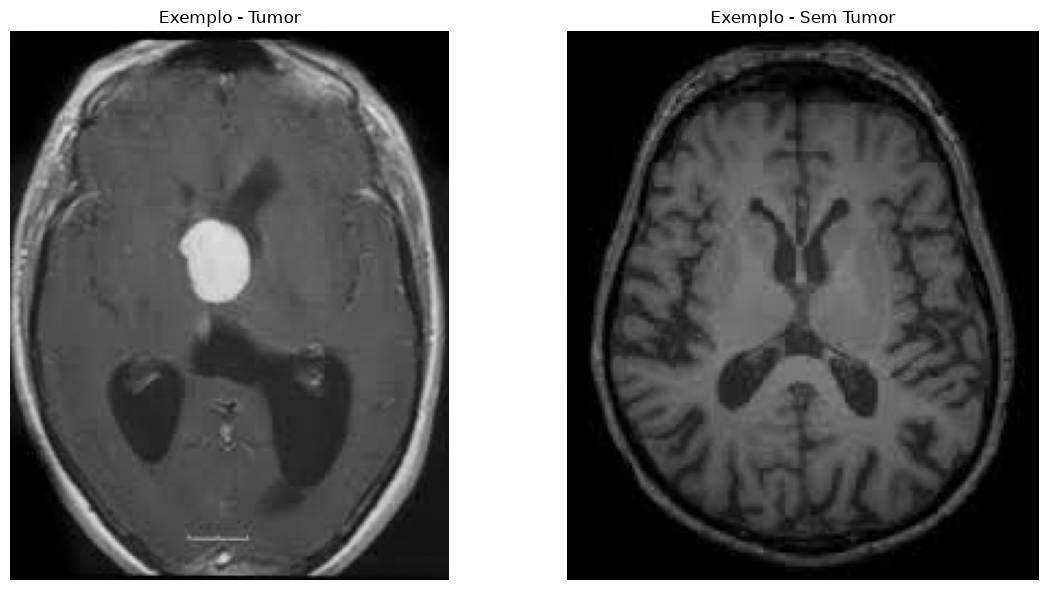

In [14]:
import random
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12, 6))

# Tumor
imagem_tumor = random.choice(imagens_tumor)
caminho = os.path.join(PASTA_TUMOR, imagem_tumor)

plt.subplot(1, 2, 1)
plt.imshow(load_img(caminho))
plt.title("Exemplo - Tumor")
plt.axis("off")

# Sem tumor
imagem_normal = random.choice(imagens_sem_tumor)
caminho = os.path.join(PASTA_SEM_TUMOR, imagem_normal)

plt.subplot(1, 2, 2)
plt.imshow(load_img(caminho))
plt.title("Exemplo - Sem Tumor")
plt.axis("off")

plt.tight_layout()
plt.show()

## Análise Visual

As imagens de ressonância magnética apresentam diferentes formatos, resoluções e características anatômicas.

Essas diferenças tornam necessário um processo de pré-processamento antes do treinamento da rede neural, incluindo:

- redimensionamento das imagens;
- normalização dos valores dos pixels;
- padronização do formato de entrada da CNN.

Essas etapas garantem que todas as imagens sejam apresentadas ao modelo de forma consistente durante o treinamento.

# 3. Pré-processamento das Imagens

Antes do treinamento da rede neural convolucional (CNN), todas as imagens passam por um processo de pré-processamento.

Essa etapa tem como objetivo padronizar os dados de entrada para que todas as imagens possuam o mesmo formato e a mesma escala de valores.

As principais etapas realizadas são:

- carregamento das imagens;
- redimensionamento para 224 × 224 pixels;
- conversão para arrays NumPy;
- normalização dos pixels para o intervalo entre 0 e 1;
- criação das variáveis de entrada (X) e saída (y).

In [15]:
X, y = carregar_dataset(CAMINHO_DATASET_BASELINE)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (253, 224, 224, 3)
Formato de y: (253,)


## Estrutura dos Dados

Após o carregamento do dataset, as imagens são armazenadas em um array denominado **X**, enquanto as classes são armazenadas em um vetor denominado **y**.

A estrutura de **X** segue o formato:

```
(número_de_imagens, altura, largura, canais)
```

onde:

- número de imagens → quantidade total do dataset;
- altura → 224 pixels;
- largura → 224 pixels;
- canais → 3 (RGB).

Já o vetor **y** contém os rótulos das classes:

- 1 → Tumor
- 0 → Sem Tumor

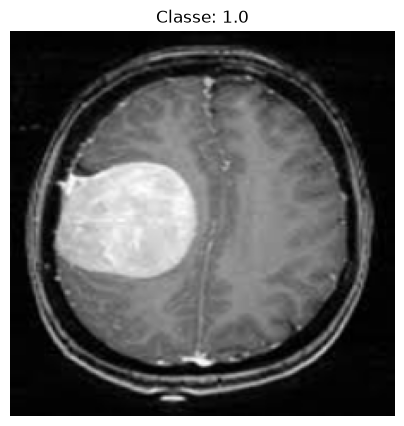

In [16]:
indice = 0

plt.figure(figsize=(5,5))
plt.imshow(X[indice])
plt.title(f"Classe: {y[indice]}")
plt.axis("off")
plt.show()

In [17]:
print("Tipo:", X.dtype)
print("Menor valor:", X.min())
print("Maior valor:", X.max())

Tipo: float32
Menor valor: 0.0
Maior valor: 1.0


## Normalização

As imagens foram normalizadas para que os valores dos pixels passassem do intervalo:

```
0 até 255
```

para

```
0 até 1
```

Essa transformação melhora a estabilidade do treinamento da rede neural, reduzindo oscilações durante a atualização dos pesos e facilitando a convergência do algoritmo de otimização.

A normalização é uma prática amplamente utilizada em modelos de Deep Learning para processamento de imagens.

# 4. Construção do Modelo Baseline

O modelo baseline foi desenvolvido utilizando uma Rede Neural Convolucional (CNN).

As CNNs são amplamente utilizadas em tarefas de visão computacional devido à sua capacidade de aprender automaticamente características relevantes das imagens, como bordas, texturas e formas.

A arquitetura utilizada neste projeto foi construída de forma simples, servindo como ponto de partida para o desenvolvimento do modelo final.

In [18]:
modelo_baseline = criar_modelo_baseline()

modelo_baseline.summary()

C:\Users\arthur fernandes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,185 (22.80 MB)

 Trainable params: 5,977,185 (22.80 MB)

 Non-trainable params: 0 (0.00 B)

## Arquitetura da Rede Neural

O modelo baseline foi implementado utilizando uma Rede Neural Convolucional (CNN) composta por sete camadas principais.

### Camada Conv2D (16 filtros)

A primeira camada convolucional possui 16 filtros com kernel 3×3.

Seu objetivo é detectar características básicas da imagem, como:

- bordas;
- linhas;
- pequenas texturas.

A saída dessa camada possui dimensão:

```
222 × 222 × 16
```

---

### MaxPooling

Após a primeira convolução é aplicada uma camada MaxPooling 2×2.

Essa camada reduz a resolução espacial da imagem pela metade, diminuindo o custo computacional e preservando apenas as características mais importantes.

Saída:

```
111 × 111 × 16
```

---

### Segunda Conv2D

A segunda camada convolucional aumenta o número de filtros para 32.

Com isso, a rede passa a aprender características mais complexas, como regiões anatômicas e padrões estruturais presentes nas imagens.

Saída:

```
109 × 109 × 32
```

---

### Segundo MaxPooling

Novamente é realizada uma redução espacial através do MaxPooling.

Saída:

```
54 × 54 × 32
```

---

### Flatten

A camada Flatten transforma toda a matriz tridimensional em um único vetor.

Antes:

```
54 × 54 × 32
```

Depois:

```
93.312 neurônios
```

Esse vetor será utilizado pelas camadas totalmente conectadas.

---

### Dense (64 neurônios)

A primeira camada totalmente conectada possui 64 neurônios.

Ela combina todas as características extraídas pelas camadas convolucionais para aprender padrões associados às duas classes.

---

### Camada de saída

A camada final possui apenas um neurônio com função de ativação Sigmoid.

Essa camada produz um valor entre 0 e 1 representando a probabilidade da imagem pertencer à classe Tumor.

## Quantidade de Parâmetros

O modelo baseline possui:

- **5.977.185 parâmetros treináveis**

Observa-se que praticamente todos os parâmetros estão concentrados na camada Dense.

Isso ocorre porque a camada Flatten gera um vetor extremamente grande (93.312 elementos), fazendo com que a conexão totalmente conectada possua milhões de pesos.

Essa característica aumenta significativamente a capacidade de aprendizado da rede, mas também favorece o overfitting quando o dataset possui poucas imagens.

# 5. Treinamento do Modelo Baseline

Após a construção da arquitetura da CNN, foi realizado o treinamento do modelo utilizando uma divisão entre conjunto de treinamento e conjunto de validação.

Durante o treinamento foi utilizada a técnica EarlyStopping para interromper automaticamente o processo caso o desempenho no conjunto de validação deixasse de melhorar, reduzindo o risco de overfitting.

## Divisão entre treinamento e avaliação

O dataset foi dividido em dois subconjuntos:

- **80% para treinamento**
- **20% para avaliação**

Foi utilizado o parâmetro `random_state=42` para garantir que a divisão possa ser reproduzida em diferentes execuções.

Também foi utilizado o parâmetro `stratify=y`, que preserva aproximadamente a mesma proporção das classes Tumor e Sem Tumor nos dois subconjuntos.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test:", X_test.shape)

print("Formato de y_train:", y_train.shape)
print("Formato de y_test:", y_test.shape)

Formato de X_train: (202, 224, 224, 3)
Formato de X_test: (51, 224, 224, 3)
Formato de y_train: (202,)
Formato de y_test: (51,)


In [20]:
classes_treino, contagens_treino = np.unique(
    y_train,
    return_counts=True
)

classes_teste, contagens_teste = np.unique(
    y_test,
    return_counts=True
)

print("Distribuição no treinamento:")

for classe, quantidade in zip(classes_treino, contagens_treino):
    nome_classe = "Tumor" if classe == 1 else "Sem tumor"
    print(f"{nome_classe}: {quantidade}")

print("\nDistribuição na avaliação:")

for classe, quantidade in zip(classes_teste, contagens_teste):
    nome_classe = "Tumor" if classe == 1 else "Sem tumor"
    print(f"{nome_classe}: {quantidade}")

Distribuição no treinamento:
Sem tumor: 78
Tumor: 124

Distribuição na avaliação:
Sem tumor: 20
Tumor: 31


## Parada antecipada — EarlyStopping

Foi utilizada a técnica EarlyStopping para acompanhar o valor da função de perda no conjunto de validação.

A configuração utilizada foi:

- monitoramento de `val_loss`;
- paciência de 3 épocas;
- restauração dos melhores pesos encontrados.

Caso a perda de validação deixe de melhorar durante três épocas consecutivas, o treinamento é interrompido.

A utilização de `restore_best_weights=True` faz com que o modelo retorne aos pesos da época em que apresentou o menor valor de perda de validação, em vez de permanecer com os pesos da última época executada.

In [22]:
parada_antecipada = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

modelo_baseline = criar_modelo_baseline()

historico_baseline = modelo_baseline.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[parada_antecipada]
)

quantidade_epocas = len(
    historico_baseline.history["loss"]
)

print(
    "Quantidade de épocas executadas:",
    quantidade_epocas
)

print(
    historico_baseline.history.keys()
)

Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 155ms/step - accuracy: 0.5743 - loss: 1.5215 - val_accuracy: 0.8039 - val_loss: 0.6552
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.7772 - loss: 0.4994 - val_accuracy: 0.8431 - val_loss: 0.4607
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.8416 - loss: 0.3903 - val_accuracy: 0.8431 - val_loss: 0.3735
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.8861 - loss: 0.3130 - val_accuracy: 0.8039 - val_loss: 0.3808
Epoch 5/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 0.8861 - loss: 0.2638 - val_accuracy: 0.8235 - val_loss: 0.3331
Epoch 6/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.9752 - loss: 0.1333 - val_accuracy: 0.8235 - val_loss: 0.4241
Epoch 7/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.9653 - loss: 0.0990 - val_accuracy: 0.8431 - val_loss: 0.4047
Epoch 8/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.9901 - loss: 0.0480 - val_accuracy: 0.8431 - val_loss:

# 6. Avaliação do Modelo Baseline

Após o treinamento, o modelo foi avaliado com base na perda e na acurácia obtidas sobre o subconjunto de avaliação.

A perda representa o erro calculado pela função Binary Crossentropy. A acurácia representa a proporção de imagens classificadas corretamente.

In [23]:
loss_baseline, accuracy_baseline = modelo_baseline.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Loss baseline: {loss_baseline:.4f}")
print(
    f"Accuracy baseline: "
    f"{accuracy_baseline * 100:.2f}%"
)

Loss baseline: 0.3331
Accuracy baseline: 82.35%


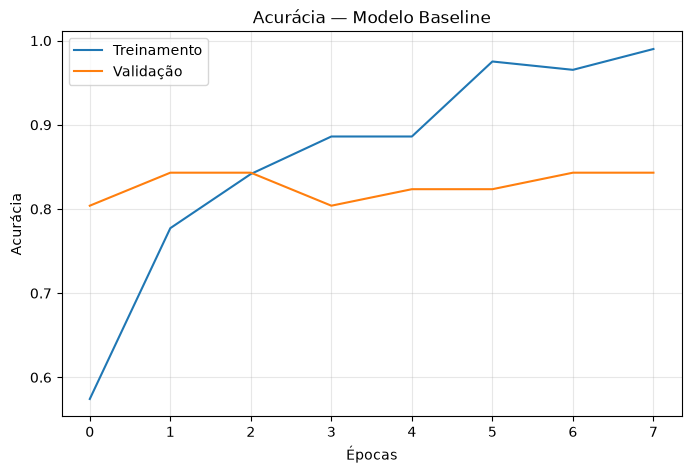

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_baseline.history["accuracy"],
    label="Treinamento"
)

plt.plot(
    historico_baseline.history["val_accuracy"],
    label="Validação"
)

plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.title("Acurácia — Modelo Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Curva de acurácia

O gráfico apresenta a evolução da acurácia durante o treinamento.

A linha de treinamento representa o desempenho sobre as imagens utilizadas para atualizar os pesos da rede. A linha de validação representa o desempenho sobre as imagens não utilizadas diretamente na atualização dos pesos.

Uma diferença muito elevada entre essas curvas pode indicar overfitting. Nesse caso, o modelo apresenta ótimo desempenho no treinamento, mas dificuldade para generalizar para imagens não vistas.

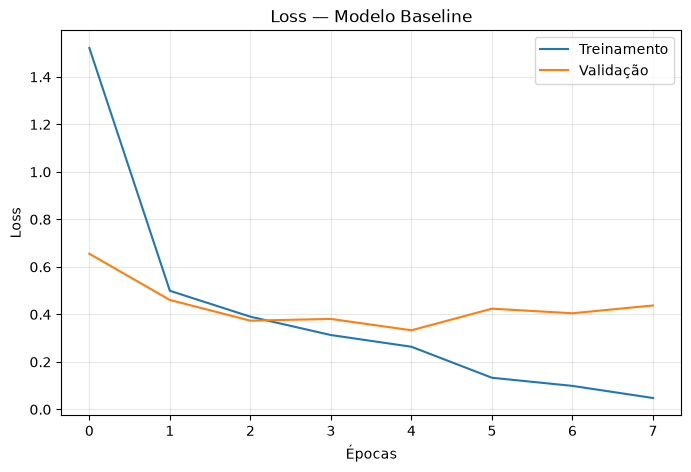

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    historico_baseline.history["loss"],
    label="Treinamento"
)

plt.plot(
    historico_baseline.history["val_loss"],
    label="Validação"
)

plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Loss — Modelo Baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Curva da função de perda

A função de perda mede a diferença entre as previsões realizadas pelo modelo e os valores reais.

Durante um treinamento adequado, espera-se que a perda de treinamento diminua progressivamente.

A perda de validação também deve diminuir. Caso a perda de treinamento continue caindo enquanto a perda de validação começa a aumentar, existe um possível sinal de overfitting.

In [27]:
probabilidades_baseline = modelo_baseline.predict(
    X_test
)

print(
    "Formato das probabilidades:",
    probabilidades_baseline.shape
)

print(
    "Primeiras probabilidades:"
)

print(
    probabilidades_baseline[:5]
)

y_pred_baseline = (
    probabilidades_baseline >= 0.5
).astype(int).ravel()

print(
    "Primeiras classes previstas:",
    y_pred_baseline[:10]
)

print(
    "Primeiras classes reais:",
    y_test[:10]
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Formato das probabilidades: (51, 1)
Primeiras probabilidades:
[[0.05706533]
 [0.974732  ]
 [0.40721646]
 [0.69069123]
 [0.04554128]]
Primeiras classes previstas: [0 1 0 1 0 1 1 1 1 1]
Primeiras classes reais: [0. 1. 0. 1. 0. 1. 1. 0. 1. 0.]


# 7. Matriz de Confusão e Métricas de Classificação

A matriz de confusão permite analisar detalhadamente os acertos e erros do modelo.

Em um problema binário, os resultados podem ser divididos em:

- Verdadeiro Negativo: imagem sem tumor classificada corretamente;
- Falso Positivo: imagem sem tumor classificada como tumor;
- Falso Negativo: imagem com tumor classificada como sem tumor;
- Verdadeiro Positivo: imagem com tumor classificada corretamente.

Matriz de confusão:
[[14  6]
 [ 3 28]]


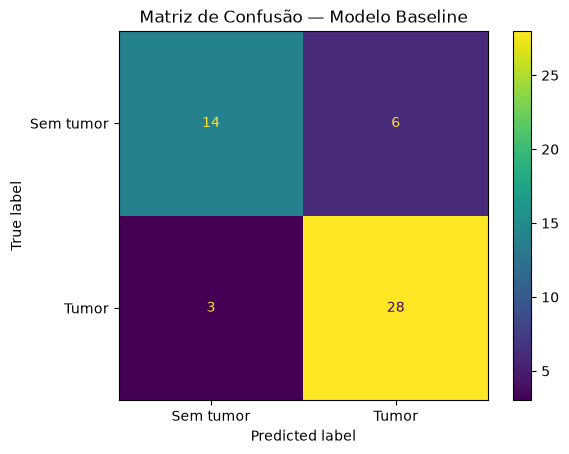

Verdadeiros negativos: 14
Falsos positivos: 6
Falsos negativos: 3
Verdadeiros positivos: 28
              precision    recall  f1-score   support

   Sem tumor       0.82      0.70      0.76        20
       Tumor       0.82      0.90      0.86        31

    accuracy                           0.82        51
   macro avg       0.82      0.80      0.81        51
weighted avg       0.82      0.82      0.82        51



In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

matriz_baseline = confusion_matrix(
    y_test,
    y_pred_baseline
)

print("Matriz de confusão:")
print(matriz_baseline)

visualizacao = ConfusionMatrixDisplay(
    confusion_matrix=matriz_baseline,
    display_labels=["Sem tumor", "Tumor"]
)

visualizacao.plot()
plt.title("Matriz de Confusão — Modelo Baseline")
plt.show()

verdadeiros_negativos, falsos_positivos, falsos_negativos, verdadeiros_positivos = (
    matriz_baseline.ravel()
)

print("Verdadeiros negativos:", verdadeiros_negativos)
print("Falsos positivos:", falsos_positivos)
print("Falsos negativos:", falsos_negativos)
print("Verdadeiros positivos:", verdadeiros_positivos)

relatorio_baseline = classification_report(
    y_test,
    y_pred_baseline,
    target_names=["Sem tumor", "Tumor"]
)

print(relatorio_baseline)

## Precision, Recall e F1-score

### Precision

A precision indica, entre todas as imagens que o modelo classificou como pertencentes a uma classe, quantas realmente pertenciam àquela classe.

Uma precision elevada para a classe Tumor significa que, quando o modelo afirma que existe tumor, ele geralmente está correto.

### Recall

O recall indica, entre todas as imagens que realmente pertencem a uma classe, quantas foram identificadas corretamente pelo modelo.

Para a classe Tumor, o recall é especialmente importante porque indica a capacidade do modelo de encontrar os casos positivos existentes no conjunto de dados.

Um recall baixo para Tumor significa que o modelo está deixando passar muitos casos positivos, produzindo falsos negativos.

### F1-score

O F1-score representa uma média harmônica entre precision e recall.

Essa métrica é útil quando se deseja considerar, ao mesmo tempo, a capacidade do modelo de evitar falsos positivos e de reduzir falsos negativos.

### Support

O support representa a quantidade real de exemplos de cada classe presente no conjunto de avaliação.

In [32]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_baseline = precision_score(
    y_test,
    y_pred_baseline
)

recall_baseline = recall_score(
    y_test,
    y_pred_baseline
)

f1_baseline = f1_score(
    y_test,
    y_pred_baseline
)

print(f"Precision baseline: {precision_baseline:.4f}")
print(f"Recall baseline: {recall_baseline:.4f}")
print(f"F1-score baseline: {f1_baseline:.4f}")

especificidade_baseline = (
    verdadeiros_negativos
    / (verdadeiros_negativos + falsos_positivos)
)

print(
    f"Especificidade baseline: "
    f"{especificidade_baseline:.4f}"
)

resultados_baseline = {
    "Modelo": "Baseline",
    "Acurácia": accuracy_baseline,
    "Precision": precision_baseline,
    "Recall": recall_baseline,
    "F1-score": f1_baseline,
    "Especificidade": especificidade_baseline,
    "Falsos positivos": falsos_positivos,
    "Falsos negativos": falsos_negativos
}

resultados_baseline

Precision baseline: 0.8235
Recall baseline: 0.9032
F1-score baseline: 0.8615
Especificidade baseline: 0.7000


{'Modelo': 'Baseline',
 'Acurácia': 0.8235294222831726,
 'Precision': 0.8235294117647058,
 'Recall': 0.9032258064516129,
 'F1-score': 0.8615384615384616,
 'Especificidade': np.float64(0.7),
 'Falsos positivos': np.int64(6),
 'Falsos negativos': np.int64(3)}

# 8. Salvamento do Modelo Baseline

Após o treinamento e a avaliação, o modelo foi salvo no formato nativo do Keras.

Esse arquivo armazena a arquitetura, os pesos aprendidos e a configuração do modelo, permitindo que ele seja carregado posteriormente sem a necessidade de realizar um novo treinamento.

In [33]:
os.makedirs(
    os.path.join(CAMINHO_PROJETO, "models"),
    exist_ok=True
)

CAMINHO_MODELO_BASELINE = os.path.join(
    CAMINHO_PROJETO,
    "models",
    "brain_tumor_baseline.keras"
)

modelo_baseline.save(
    CAMINHO_MODELO_BASELINE
)

print("Modelo salvo em:")
print(CAMINHO_MODELO_BASELINE)

Modelo salvo em:
c:\Users\arthur fernandes\Documents\Medical_AI_Project\BRAIN_TUMOR_DETECTION_AI\models\brain_tumor_baseline.keras


# 9. Conclusão do Modelo Baseline

O modelo baseline foi desenvolvido como uma primeira abordagem para a classificação binária de imagens de ressonância magnética entre as classes Tumor e Sem Tumor.

A arquitetura utilizada foi capaz de aprender padrões presentes nas imagens, mas apresentou limitações importantes:

- dataset reduzido, com apenas 253 imagens;
- leve desbalanceamento entre as classes;
- grande quantidade de parâmetros em relação ao tamanho do dataset;
- risco elevado de overfitting;
- utilização do mesmo conjunto para validação durante o treinamento e avaliação final.

Essas limitações motivaram a criação da versão V2, que utiliza um dataset significativamente maior, técnicas adicionais de regularização e uma arquitetura mais adequada para melhorar a capacidade de generalização.

# 10. Comparação entre o Modelo Baseline e o Modelo V2

Nesta etapa são comparados os resultados obtidos pelo modelo baseline e pelo modelo V2.

O objetivo é verificar se as alterações realizadas na segunda versão contribuíram para:

- melhorar a acurácia;
- aumentar a capacidade de identificar imagens com tumor;
- reduzir falsos positivos;
- reduzir falsos negativos;
- melhorar a capacidade de generalização do modelo.

In [35]:
vn_v2 = 385
fp_v2 = 15
fn_v2 = 81
vp_v2 = 1119

accuracy_v2 = (vn_v2 + vp_v2) / (
    vn_v2 + fp_v2 + fn_v2 + vp_v2
)

precision_v2 = vp_v2 / (
    vp_v2 + fp_v2
)

recall_v2 = vp_v2 / (
    vp_v2 + fn_v2
)

f1_v2 = 2 * (
    precision_v2 * recall_v2
) / (
    precision_v2 + recall_v2
)

especificidade_v2 = vn_v2 / (
    vn_v2 + fp_v2
)

print(f"Acurácia V2: {accuracy_v2:.4f}")
print(f"Precision V2: {precision_v2:.4f}")
print(f"Recall V2: {recall_v2:.4f}")
print(f"F1-score V2: {f1_v2:.4f}")
print(f"Especificidade V2: {especificidade_v2:.4f}")

resultados_v2 = {
    "Modelo": "V2",
    "Acurácia": accuracy_v2,
    "Precision": precision_v2,
    "Recall": recall_v2,
    "F1-score": f1_v2,
    "Especificidade": especificidade_v2,
    "Falsos positivos": fp_v2,
    "Falsos negativos": fn_v2
}

resultados_v2

Acurácia V2: 0.9400
Precision V2: 0.9868
Recall V2: 0.9325
F1-score V2: 0.9589
Especificidade V2: 0.9625


{'Modelo': 'V2',
 'Acurácia': 0.94,
 'Precision': 0.9867724867724867,
 'Recall': 0.9325,
 'F1-score': 0.9588688946015425,
 'Especificidade': 0.9625,
 'Falsos positivos': 15,
 'Falsos negativos': 81}

In [38]:
import pandas as pd

tabela_exibicao = tabela_comparacao.copy()

colunas_percentuais = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-score",
    "Especificidade"
]

for coluna in colunas_percentuais:
    tabela_exibicao[coluna] = (
        tabela_exibicao[coluna] * 100
    ).round(2)

tabela_exibicao

,Modelo,Acurácia,Precision,Recall,F1-score,Especificidade,Falsos positivos,Falsos negativos
0,Baseline,82.35,82.35,90.32,86.15,70.00,6,3
1,V2,94.00,98.68,93.25,95.89,96.25,15,81


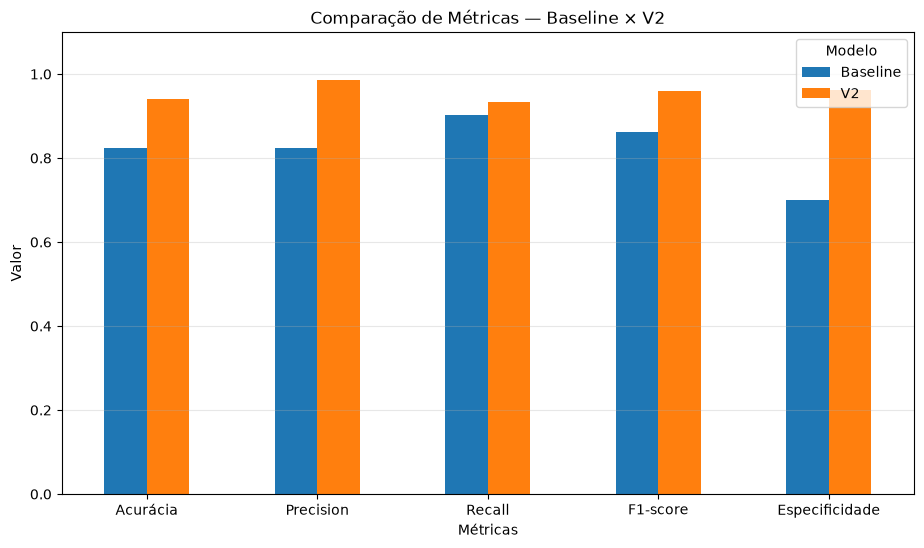

In [39]:
metricas = [
    "Acurácia",
    "Precision",
    "Recall",
    "F1-score",
    "Especificidade"
]

comparacao_metricas = tabela_comparacao.set_index(
    "Modelo"
)[metricas].T

comparacao_metricas.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparação de Métricas — Baseline × V2")
plt.xlabel("Métricas")
plt.ylabel("Valor")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y", alpha=0.3)
plt.show()

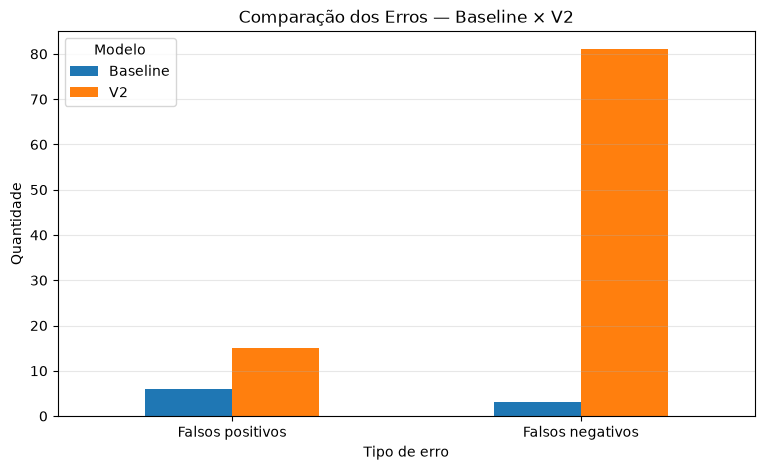

In [40]:
erros_comparacao = tabela_comparacao.set_index(
    "Modelo"
)[
    [
        "Falsos positivos",
        "Falsos negativos"
    ]
].T

erros_comparacao.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Comparação dos Erros — Baseline × V2"
)

plt.xlabel("Tipo de erro")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)
plt.legend(title="Modelo")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [41]:
taxa_fp_baseline = falsos_positivos / (
    falsos_positivos + verdadeiros_negativos
)

taxa_fn_baseline = falsos_negativos / (
    falsos_negativos + verdadeiros_positivos
)

taxa_fp_v2 = fp_v2 / (
    fp_v2 + vn_v2
)

taxa_fn_v2 = fn_v2 / (
    fn_v2 + vp_v2
)

print(
    f"Taxa de falso positivo baseline: "
    f"{taxa_fp_baseline * 100:.2f}%"
)

print(
    f"Taxa de falso negativo baseline: "
    f"{taxa_fn_baseline * 100:.2f}%"
)

print(
    f"Taxa de falso positivo V2: "
    f"{taxa_fp_v2 * 100:.2f}%"
)

print(
    f"Taxa de falso negativo V2: "
    f"{taxa_fn_v2 * 100:.2f}%"
)

Taxa de falso positivo baseline: 30.00%
Taxa de falso negativo baseline: 9.68%
Taxa de falso positivo V2: 3.75%
Taxa de falso negativo V2: 6.75%


## Interpretação dos resultados da V2

O modelo V2 apresentou acurácia aproximada de 94%, indicando que a maior parte das imagens foi classificada corretamente.

A precision da classe Tumor foi elevada, próxima de 98,68%. Isso significa que, entre as imagens classificadas como tumor, a grande maioria realmente pertencia à classe positiva.

O recall foi de aproximadamente 93,25%, indicando que o modelo conseguiu identificar a maior parte das imagens que realmente possuíam tumor.

A especificidade foi de aproximadamente 96,25%, demonstrando boa capacidade de reconhecer corretamente imagens sem tumor.

Apesar do bom desempenho geral, foram observados 81 falsos negativos. Esses casos representam imagens com tumor classificadas incorretamente como sem tumor e devem receber atenção especial em aplicações relacionadas à saúde.

## Conclusão da comparação

A comparação entre os modelos permite avaliar o impacto das melhorias implementadas na versão V2.

O modelo baseline foi treinado com apenas 253 imagens e possuía aproximadamente 5,9 milhões de parâmetros, característica que aumentava o risco de overfitting.

A versão V2 utilizou um conjunto de dados significativamente maior, com 5.600 imagens de treinamento e 1.600 imagens de teste.

O aumento da quantidade de dados contribuiu para uma avaliação mais representativa e para uma melhor capacidade de generalização.

Entretanto, os resultados devem ser analisados não apenas pela acurácia, mas também por métricas como recall, especificidade, F1-score e pelas taxas de falsos positivos e falsos negativos.

# 11. Auditoria de Reprodutibilidade e Vazamento de Dados

Além da avaliação dos resultados obtidos, foi realizada uma análise da metodologia empregada durante o desenvolvimento do modelo baseline e do modelo V2.

O objetivo desta auditoria é identificar possíveis fatores que possam influenciar os resultados obtidos, bem como garantir a transparência e a reprodutibilidade do experimento.

## Reprodutibilidade

Para tornar os experimentos reproduzíveis, foi utilizado:

- `random_state=42` na divisão dos dados;
- mesma arquitetura durante todas as execuções;
- mesmo processo de pré-processamento;
- mesmos hiperparâmetros de treinamento.

Essas configurações permitem reproduzir resultados semelhantes em diferentes execuções do projeto.

## Controle de Overfitting

O treinamento utilizou o callback EarlyStopping monitorando a perda de validação (`val_loss`).

Quando a perda deixou de apresentar melhora durante três épocas consecutivas, o treinamento foi interrompido automaticamente.

Além disso, foi utilizado `restore_best_weights=True`, garantindo que o modelo final correspondesse à época com melhor desempenho observado durante o treinamento.

## Limitações do Modelo Baseline

Durante a análise metodológica foram identificadas algumas limitações importantes:

- pequeno número de imagens disponíveis (253);
- grande quantidade de parâmetros treináveis (aproximadamente 5,9 milhões);
- elevado risco de overfitting;
- utilização do mesmo conjunto de dados para validação durante o treinamento e avaliação final.

## Melhorias Implementadas na Versão V2

Na segunda versão do projeto foram realizadas melhorias importantes:

- utilização de um conjunto de dados significativamente maior;
- melhor capacidade de generalização;
- maior precisão na identificação de tumores;
- aumento da especificidade;
- melhor equilíbrio entre precision, recall e F1-score.

## Considerações Éticas

O modelo desenvolvido possui finalidade exclusivamente educacional e de pesquisa.

As previsões produzidas não devem ser interpretadas como diagnóstico médico.

A decisão clínica deve sempre ser realizada por profissionais qualificados, considerando o histórico do paciente, exames complementares e avaliação médica especializada.

Além disso, modelos treinados em bases específicas podem apresentar limitações quando aplicados a populações diferentes daquelas utilizadas durante o treinamento.